Разработка методов гибридизации машинного обучения и символьной регрессии для построения адаптивных моделей принятия решений

# Подготовка

In [4]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd

from sklearn.model_selection import train_test_split
from sklearn.datasets import fetch_california_housing
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor

In [5]:
data = fetch_california_housing()
X, y = data.data, data.target
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [6]:
models = {"RandomForest": RandomForestRegressor(n_estimators=200, random_state=42),
          "XGBoost": XGBRegressor(n_estimators=200, random_state=42),
          "LightGBM": LGBMRegressor(n_estimators=200, random_state=42, force_col_wise=True)}
print('------------------------------------------')
for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    print(name)
    print("RMSE", np.sqrt(mean_squared_error(y_test, y_pred)))
    print("MAE", mean_absolute_error(y_test, y_pred))
    print("R2", r2_score(y_test, y_pred))
    print('------------------------------------------')


------------------------------------------
RandomForest
RMSE 0.5039602414072009
MAE 0.32681185043604677
R2 0.8061857564039718
------------------------------------------
XGBoost
RMSE 0.46933861520459214
MAE 0.30711598373764826
R2 0.8319007734380242
------------------------------------------
[LightGBM] [Info] Total Bins 1838
[LightGBM] [Info] Number of data points in the train set: 16512, number of used features: 8
[LightGBM] [Info] Start training from score 2.071947
LightGBM
RMSE 0.44832525930653183
MAE 0.29413456280902894
R2 0.8466161774913306
------------------------------------------


In [7]:
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim

from sklearn.preprocessing import StandardScaler

In [10]:
def prepare_torch_data(X_train, X_val, X_test, y_train, y_val, y_test):
    scaler = StandardScaler()

    X_train = scaler.fit_transform(X_train)
    X_val = scaler.transform(X_val)
    X_test = scaler.transform(X_test)

    X_train = torch.FloatTensor(X_train)
    X_val = torch.FloatTensor(X_val)
    X_test = torch.FloatTensor(X_test)

    y_train = torch.FloatTensor(y_train.values if hasattr(y_train, "values") else y_train).view(-1, 1)
    y_val = torch.FloatTensor(y_val.values if hasattr(y_val, "values") else y_val).view(-1, 1)
    y_test = torch.FloatTensor(y_test.values if hasattr(y_test, "values") else y_test).view(-1, 1)
    return X_train, X_val, X_test, y_train, y_val, y_test

class MLPRegressor(nn.Module):
    def __init__(self, input_dim):
        super(MLPRegressor, self).__init__()
        self.model = nn.Sequential(
            nn.Linear(input_dim, 128),
            nn.BatchNorm1d(128),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(128, 64),
            nn.BatchNorm1d(64),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(64, 1))
        
    def forward(self, x):
        return self.model(x)



def train_model(model, X_train, y_train, X_val, y_val, epochs=500, lr=1e-3, patience=400):
    criterion = nn.MSELoss()
    optimizer = optim.Adam(model.parameters(), lr=lr)
    best_val_loss = np.inf
    patience_counter = 0

    for epoch in range(epochs):
        model.train()
        optimizer.zero_grad()
        outputs = model(X_train)
        loss = criterion(outputs, y_train)
        loss.backward()
        optimizer.step()

        model.eval()
        with torch.no_grad():
            val_outputs = model(X_val)
            val_loss = criterion(val_outputs, y_val)

        if val_loss.item() < best_val_loss:
            best_val_loss = val_loss.item()
            best_weights = model.state_dict()
            patience_counter = 0
        else:
            patience_counter += 1

        if patience_counter >= patience:
            print(f"Early stopping at epoch {epoch}")
            break

    model.load_state_dict(best_weights)
    return model



def evaluate_model(model, X_test, y_test):
    model.eval()
    with torch.no_grad():
        predictions = model(X_test).numpy()

    y_true = y_test.numpy()
    return {"RMSE": np.sqrt(mean_squared_error(y_true, predictions)),
            "MAE": mean_absolute_error(y_true, predictions),
            "R2": r2_score(y_true, predictions)}



def run_dl_pipeline(X, y):
    X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.3)
    X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5)
    X_train, X_val, X_test, y_train, y_val, y_test = prepare_torch_data(X_train, X_val, X_test, y_train, y_val, y_test)

    model = MLPRegressor(input_dim=X_train.shape[1])
    model = train_model(model, X_train, y_train, X_val, y_val)
    results = evaluate_model(model, X_test, y_test)
    return results

In [11]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
dl_results = run_dl_pipeline(X, y)
for m, v in dl_results.items():
    print(f"{m}: {v:.4f}")

RMSE: 0.5877
MAE: 0.3971
R2: 0.7388


In [12]:
class ResidualBlock(nn.Module):
    def __init__(self, dim):
        super().__init__()
        self.block = nn.Sequential(
            nn.Linear(dim, dim),
            nn.BatchNorm1d(dim),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(dim, dim),
            nn.BatchNorm1d(dim))
        self.act = nn.ReLU()

    def forward(self, x):
        return self.act(x + self.block(x))


class ResMLP(nn.Module):
    def __init__(self, input_dim):
        super().__init__()
        self.input_layer = nn.Sequential(
            nn.Linear(input_dim, 256),
            nn.BatchNorm1d(256),
            nn.ReLU())

        self.blocks = nn.Sequential(
            ResidualBlock(256),
            ResidualBlock(256),
            ResidualBlock(256))

        self.output = nn.Linear(256, 1)

    def forward(self, x):
        x = self.input_layer(x)
        x = self.blocks(x)
        return self.output(x)

In [13]:
def train_dl(model, X_train, y_train, X_val, y_val, epochs=300, patience=20):
    optimizer = optim.Adam(model.parameters(), lr=1e-3)
    criterion = nn.MSELoss()
    best_loss = np.inf
    patience_counter = 0

    for epoch in range(epochs):
        model.train()
        optimizer.zero_grad()
        loss = criterion(model(X_train), y_train)
        loss.backward()
        optimizer.step()

        model.eval()
        with torch.no_grad():
            val_loss = criterion(model(X_val), y_val)
        if val_loss < best_loss:
            best_loss = val_loss
            best_weights = model.state_dict()
            patience_counter = 0
        else:
            patience_counter += 1
        if patience_counter >= patience:
            break
    model.load_state_dict(best_weights)
    return model

In [14]:
X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.3)
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5)

scaler = StandardScaler()

X_train_s = torch.FloatTensor(scaler.fit_transform(X_train))
X_val_s = torch.FloatTensor(scaler.transform(X_val))
X_test_s = torch.FloatTensor(scaler.transform(X_test))

y_train_t = torch.FloatTensor(y_train).view(-1, 1)
y_val_t = torch.FloatTensor(y_val).view(-1, 1)
y_test_t = torch.FloatTensor(y_test).view(-1, 1)

In [15]:
def evaluate(y_true, y_pred):
    return {"RMSE": np.sqrt(mean_squared_error(y_true, y_pred)),
            "MAE": mean_absolute_error(y_true, y_pred),
            "R2": r2_score(y_true, y_pred)}

In [16]:
resmlp = ResMLP(X_train.shape[1])
resmlp = train_dl(resmlp, X_train_s, y_train_t, X_val_s, y_val_t)

res_preds = resmlp(X_test_s).detach().numpy()
res_results = evaluate(y_test, res_preds)

In [17]:
res_results

{'RMSE': 0.5530375638225653,
 'MAE': 0.36640743463044484,
 'R2': 0.7716752934305732}

# Имплементация gplearn и PySR

In [ ]:
import numpy as np
import pandas as pd
import time
import warnings
warnings.filterwarnings('ignore')
import matplotlib.pyplot as plt
from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.preprocessing import StandardScaler
from gplearn.genetic import SymbolicRegressor

In [22]:
data = fetch_california_housing()
X, y = data.data, data.target
feature_names = data.feature_names

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)
gp1 = SymbolicRegressor(population_size=500,
                        generations=15,
                        tournament_size=20,
                        stopping_criteria=0.01,
                        function_set=('add', 'sub', 'mul', 'div', 'sqrt', 'log', 'neg'),
                        p_crossover=0.7,
                        p_subtree_mutation=0.1,
                        p_hoist_mutation=0.05,
                        p_point_mutation=0.1,
                        parsimony_coefficient=0.001,
                        max_samples=0.9,
                        feature_names=feature_names)
print("Обучение gplearn")
start_time = time.time()
gp1.fit(X_train_scaled, y_train)
gplearn_time1 = time.time() - start_time

y_pred_gp1 = gp1.predict(X_test_scaled)
gplearn_mse1 = mean_squared_error(y_test, y_pred_gp1)
gplearn_r2_1 = r2_score(y_test, y_pred_gp1)
print("РЕЗУЛЬТАТЫ GPLEARN")
print(f"Время обучения: {gplearn_time1:.2f} сек")
print(f"MSE: {gplearn_mse1:.4f}")
print(f"R2: {gplearn_r2_1:.4f}")
print(f"Лучшее выражение:")
print(str(gp1._program))

Обучение gplearn
РЕЗУЛЬТАТЫ GPLEARN
Время обучения: 10.32 сек
MSE: 0.7751
R2: 0.4165
Лучшее выражение:
add(add(sqrt(-0.814), div(Population, Population)), MedInc)


In [25]:
from pysr import PySRRegressor

start_time = time.time()

pysr_model = PySRRegressor(populations=8,
                           population_size=50,
                           niterations=40,
                           unary_operators=["exp", "log", "sqrt", "neg"],
                           binary_operators=["+", "-", "*", "/"],
                           maxsize=20,
                           maxdepth=5,
                           parsimony=0.001,
                           procs=4,
                           multithreading=True,
                           progress=True,
                           tempdir="pysr_temp",
                           delete_tempfiles=True)

print("Обучение PySR")
X_train_df = pd.DataFrame(X_train_scaled, columns=feature_names)
pysr_model.fit(X_train_df, y_train)
pysr_time = time.time() - start_time

X_test_df = pd.DataFrame(X_test_scaled, columns=feature_names)
y_pred_pysr = pysr_model.predict(X_test_df)

pysr_mse = mean_squared_error(y_test, y_pred_pysr)
pysr_r2 = r2_score(y_test, y_pred_pysr)

print(f"Время обучения: {pysr_time:.2f} сек")
print(f"MSE: {pysr_mse:.4f}")
print(f"R2: {pysr_r2:.4f}")

best_equation = pysr_model.equations_.iloc[-1]['equation']
print(f"Лучшее выражение:")
print(best_equation)

Обучение PySR


[ Info: Note: you are running with more than 10,000 datapoints. You should consider turning on batching (`options.batching`), and also if you need that many datapoints. Unless you have a large amount of noise (in which case you should smooth your dataset first), generally < 10,000 datapoints is enough to find a functional form.
[ Info: Started!



Expressions evaluated per second: 2.030e+04
Progress: 66 / 320 total iterations (20.625%)
════════════════════════════════════════════════════════════════════════════════════════════════════
───────────────────────────────────────────────────────────────────────────────────────────────────
Complexity  Loss       Score      Equation
1           1.332e+00  0.000e+00  y = 2.0696
3           7.412e-01  2.932e-01  y = MedInc + 2.0696
5           6.994e-01  2.902e-02  y = (MedInc * 0.79555) + 2.0696
10          6.434e-01  1.671e-02  y = neg(Latitude) + ((neg(Longitude) + 2.0696) - neg(MedIn...
                                      c))
11          5.541e-01  1.493e-01  y = (neg(Latitude) + (neg(Longitude) + 2.0696)) - (MedInc ...
                                      * -0.70124)
───────────────────────────────────────────────────────────────────────────────────────────────────
════════════════════════════════════════════════════════════════════════════════════════════════════
Press 'q' and t

[ Info: Final population:
[ Info: Results saved to:



Expressions evaluated per second: 2.290e+04
Progress: 213 / 320 total iterations (66.562%)
════════════════════════════════════════════════════════════════════════════════════════════════════
───────────────────────────────────────────────────────────────────────────────────────────────────
Complexity  Loss       Score      Equation
1           1.332e+00  0.000e+00  y = 2.0696
3           7.412e-01  2.932e-01  y = MedInc + 2.0696
5           6.994e-01  2.902e-02  y = (MedInc * 0.79555) + 2.0696
9           6.832e-01  5.876e-03  y = (HouseAge * 0.24094) + (neg(neg(MedInc)) + 2.0696)
10          6.434e-01  6.003e-02  y = neg(Latitude) + ((neg(Longitude) + 2.0696) - neg(MedIn...
                                      c))
11          5.541e-01  1.493e-01  y = ((neg(Latitude) + neg(Longitude)) + 2.0696) - (MedInc ...
                                      * -0.70124)
14          5.529e-01  7.709e-04  y = ((Latitude * -2.2882) / 2.2089) - ((neg(MedInc) * 0.69...
                              

In [27]:
from gplearn.genetic import SymbolicRegressor
rf = RandomForestRegressor(n_estimators=200)
rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_train)
residuals_rf = y_train - y_pred_rf

gp_rf = SymbolicRegressor(population_size=2000,
                          generations=30,
                          stopping_criteria=0.001,
                          p_crossover=0.7,
                          p_subtree_mutation=0.1,
                          p_hoist_mutation=0.05,
                          p_point_mutation=0.1,
                          max_samples=0.9)

gp_rf.fit(X_train, residuals_rf)

y_test_rf = rf.predict(X_test)
res_test_rf = gp_rf.predict(X_test)

y_final_rf = y_test_rf + res_test_rf
display(y_final_rf)
display(mean_squared_error(y_test, y_final_rf))
display(r2_score(y_test, y_final_rf))

array([2.51473021, 2.48667011, 3.01081516, ..., 1.36041031, 3.04859166,
       1.91974011])

0.25175704928100395

0.8104757081641334

In [28]:
from pysr import PySRRegressor

pysr_rf = PySRRegressor(niterations=40,
                        binary_operators=["+", "-", "*", "/"],
                        unary_operators=["sin", "cos", "exp", "log"],
                        model_selection="best")

pysr_rf.fit(X_train, residuals_rf)

res_test_rf = pysr_rf.predict(X_test)
y_final_rf = y_test_rf + res_test_rf
display(mean_squared_error(y_test, y_final_rf))
display(r2_score(y_test, y_final_rf))

[ Info: Note: you are running with more than 10,000 datapoints. You should consider turning on batching (`options.batching`), and also if you need that many datapoints. Unless you have a large amount of noise (in which case you should smooth your dataset first), generally < 10,000 datapoints is enough to find a functional form.
[ Info: Started!



Expressions evaluated per second: 6.870e+01
Progress: 1 / 1240 total iterations (0.081%)
════════════════════════════════════════════════════════════════════════════════════════════════════
───────────────────────────────────────────────────────────────────────────────────────────────────
Complexity  Loss       Score      Equation
2           3.116e-01  0.000e+00  y = sin(0.54975)
3           2.275e-01  3.148e-01  y = sin(exp(-0.79776))
4           3.962e-02  1.748e+00  y = cos(exp(exp(-0.89436)))
5           3.484e-02  1.284e-01  y = sin(sin(x₄) / x₄)
7           3.481e-02  4.273e-04  y = sin((sin(-1.5146) / x₄) * 1.3574)
8           3.481e-02  9.877e-05  y = sin(sin(-1.5146 - cos(x₅)) / x₄)
13          3.479e-02  9.690e-05  y = sin(sin(-1.5146 - (-0.088748 - (0.23218 - exp(cos(x₁))...
                                      ))) / x₄)
14          3.478e-02  3.365e-04  y = sin(((-1.5146 - (0.23218 - (exp(cos(x₁)) - -0.088748))...
                                      ) / x₄) * 1.3574)
1

[ Info: Final population:
[ Info: Results saved to:


0.2490312467251044

0.8125277094906767

In [29]:
xgb = XGBRegressor(n_estimators=200)
xgb.fit(X_train, y_train)

y_pred_xgb = xgb.predict(X_train)
residuals_xgb = y_train - y_pred_xgb

gp_xgb = SymbolicRegressor(population_size=2000,
                           generations=30)

gp_xgb.fit(X_train, residuals_xgb)

y_final_xgb = xgb.predict(X_test) + gp_xgb.predict(X_test)
display(mean_squared_error(y_test, y_final_xgb))
display(r2_score(y_test, y_final_xgb))

0.2131470365233878

0.8395415688681701

In [30]:
pysr_xgb = PySRRegressor(niterations=40,
                         binary_operators=["+", "-", "*", "/"],
                         unary_operators=["exp", "log"])

pysr_xgb.fit(X_train, residuals_xgb)

y_final_xgb = xgb.predict(X_test) + pysr_xgb.predict(X_test)
display(mean_squared_error(y_test, y_final_xgb))
display(r2_score(y_test, y_final_xgb))

[ Info: Note: you are running with more than 10,000 datapoints. You should consider turning on batching (`options.batching`), and also if you need that many datapoints. Unless you have a large amount of noise (in which case you should smooth your dataset first), generally < 10,000 datapoints is enough to find a functional form.
[ Info: Started!



Expressions evaluated per second: 6.890e+03
Progress: 46 / 1240 total iterations (3.710%)
════════════════════════════════════════════════════════════════════════════════════════════════════
───────────────────────────────────────────────────────────────────────────────────────────────────
Complexity  Loss       Score      Equation
1           9.631e-02  0.000e+00  y = 0.24718
2           3.523e-02  1.006e+00  y = exp(x₇)
4           3.523e-02  1.431e-06  y = exp(x₁ / -0.19402)
5           3.523e-02  1.436e-05  y = (x₅ / x₇) / x₇
8           3.523e-02  2.277e-05  y = exp(0.72211 * (x₇ / (x₂ / x₅)))
10          3.523e-02  5.394e-06  y = 0.72211 * exp((x₇ * 0.72211) / (x₂ / x₅))
17          3.522e-02  3.968e-05  y = (((-0.08596 - x₃) * x₀) * 0.029532) / ((x₄ - -1.2087) ...
                                      + ((0.41622 - x₃) * x₃))
───────────────────────────────────────────────────────────────────────────────────────────────────
══════════════════════════════════════════════════════

[ Info: Final population:
[ Info: Results saved to:


0.21309916057609954

0.8395776101827299

  - outputs\20260222_183111_sMx7JN\hall_of_fame.csv


In [31]:
lgbm = LGBMRegressor(n_estimators=200)
lgbm.fit(X_train, y_train)

residuals_lgbm = y_train - lgbm.predict(X_train)

gp_lgbm = SymbolicRegressor(population_size=2000,
                            generations=30)

gp_lgbm.fit(X_train, residuals_lgbm)

y_final_lgbm = lgbm.predict(X_test) + gp_lgbm.predict(X_test)
display(mean_squared_error(y_test, y_final_lgbm))
display(r2_score(y_test, y_final_lgbm))

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000542 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1838
[LightGBM] [Info] Number of data points in the train set: 16512, number of used features: 8
[LightGBM] [Info] Start training from score 2.069599


0.20320054775410837

0.84702934823973

In [59]:
pysr_lgbm = PySRRegressor(
    niterations=40,
    binary_operators=["+", "-", "*", "/"],
    unary_operators=["sin", "cos"]
)

pysr_lgbm.fit(X_train, residuals_lgbm)

y_final_lgbm = lgbm.predict(X_test) + pysr_lgbm.predict(X_test)
display(mean_squared_error(y_test, y_final_lgbm))
display(r2_score(y_test, y_final_lgbm))

[ Info: Note: you are running with more than 10,000 datapoints. You should consider turning on batching (`options.batching`), and also if you need that many datapoints. Unless you have a large amount of noise (in which case you should smooth your dataset first), generally < 10,000 datapoints is enough to find a functional form.
[ Info: Started!



Expressions evaluated per second: 2.310e+04
Progress: 141 / 1240 total iterations (11.371%)
════════════════════════════════════════════════════════════════════════════════════════════════════
───────────────────────────────────────────────────────────────────────────────────────────────────
Complexity  Loss       Score      Equation
1           1.166e-01  0.000e+00  y = -5.5391e-08
3           1.166e-01  7.332e-05  y = x₂ * 0.00069651
4           1.165e-01  3.288e-04  y = sin(x₁) / x₄
5           1.164e-01  1.016e-03  y = (x₃ * x₃) * 0.0020282
6           1.163e-01  7.859e-04  y = x₃ / (x₄ / sin(x₁))
8           1.162e-01  6.060e-04  y = sin(x₁) / ((x₄ / x₃) - 0.74452)
24          1.161e-01  1.744e-05  y = (cos(x₃) * (x₀ * (0.06112 / ((x₄ - x₃) + (0.38909 - ((...
                                      1.0841 - ((x₆ / x₃) * -0.29668)) * 2.3179)))))) * x₃
26          1.161e-01  1.624e-05  y = x₃ * ((cos(x₃) * (x₀ * 0.06112)) / ((x₄ - (x₃ + 0.3890...
                                     

[ Info: Final population:
[ Info: Results saved to:


0.2021944163972141

0.8457012888688835

  - outputs\20260218_143815_AcdvmU\hall_of_fame.csv


In [32]:
resmlp = ResMLP(X_train.shape[1])
resmlp = train_dl(resmlp, X_train_s, y_train_t, X_val_s, y_val_t)

y_pred_res = resmlp(X_train_s).detach().numpy().ravel()
residuals_res = y_train_t.detach().numpy().ravel() - y_pred_res

gp_res = SymbolicRegressor(population_size=2000,
                           generations=30)

gp_res.fit(X_train_s, residuals_res)

y_final_res = (resmlp(X_test_s).detach().cpu().numpy().ravel() + gp_res.predict(X_test_s))
display(mean_squared_error(y_test_t, y_final_res))
display(r2_score(y_test_t, y_final_res))

0.3180175259830306

0.7625923552017322

In [33]:
pysr_res = PySRRegressor(niterations=40,
                         binary_operators=["+", "-", "*", "/"],
                         unary_operators=["sin", "cos", "exp"])

pysr_res.fit(X_train_s, residuals_res)

y_final_res = (resmlp(X_test_s).detach().numpy().ravel() + pysr_res.predict(X_test_s))
display(mean_squared_error(y_test_t, y_final_res))
display(r2_score(y_test_t, y_final_res))

[ Info: Note: you are running with more than 10,000 datapoints. You should consider turning on batching (`options.batching`), and also if you need that many datapoints. Unless you have a large amount of noise (in which case you should smooth your dataset first), generally < 10,000 datapoints is enough to find a functional form.
[ Info: Started!



Expressions evaluated per second: 1.420e+02
Progress: 17 / 1240 total iterations (1.371%)
════════════════════════════════════════════════════════════════════════════════════════════════════
───────────────────────────────────────────────────────────────────────────────────────────────────
Complexity  Loss       Score      Equation
1           2.639e-01  0.000e+00  y = 0.083501
5           2.606e-01  3.134e-03  y = (x₅ - -1.8969) * 0.034799
7           2.592e-01  2.844e-03  y = ((x₅ / 5.9809) * 0.41294) + 0.083502
9           2.583e-01  1.705e-03  y = (((x₅ - x₆) - -1.5756) * 0.015838) / 0.29863
───────────────────────────────────────────────────────────────────────────────────────────────────
════════════════════════════════════════════════════════════════════════════════════════════════════
Press 'q' and then <enter> to stop execution early.

Expressions evaluated per second: 9.770e+03
Progress: 102 / 1240 total iterations (8.226%)
═══════════════════════════════════════════════════

[ Info: Final population:
[ Info: Results saved to:


0.3140315402457738

0.7655679883312476

# Рассмотрим на случайно сгенерированном ряде

In [37]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.tsa.arima.model import ARIMA
from pysr import PySRRegressor

In [38]:
n = 300
t = np.arange(n)
y = 0.5 * t + 10 * np.sin(0.2 * t) + np.random.normal(0, 3, n)
y = pd.Series(y)

In [39]:
model = ARIMA(y, order=(3,1,2))
arima_fit = model.fit()

arima_pred = arima_fit.predict(start=1, end=len(y)-1)
arima_pred = np.concatenate([[y.iloc[0]], arima_pred])
residuals = y - arima_pred

c:\Users\Ivan\AppData\Local\Programs\Python\Python312\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


In [40]:
def make_lags(series, nlags=10):
    df = pd.DataFrame({"y": series})
    for i in range(1, nlags + 1):
        df[f"lag_{i}"] = df["y"].shift(i)
    return df.dropna()

lagged = make_lags(residuals, nlags=10)
X = lagged.drop(columns=["y"]).values
y_res = lagged["y"].values

In [41]:
sr = PySRRegressor(niterations=50,
                   populations=20,
                   unary_operators=["sin", "cos", "exp"],
                   binary_operators=["+", "-", "*", "/"],
                   loss="loss(x, y) = (x - y)^2",
                   model_selection="best")

sr.fit(X, y_res)
residual_pred = sr.predict(X)
hybrid_pred = arima_pred[-len(residual_pred):] + residual_pred

[ Info: Started!
[ Info: Final population:
[ Info: Results saved to:



Expressions evaluated per second: 1.640e+05
Progress: 870 / 1000 total iterations (87.000%)
════════════════════════════════════════════════════════════════════════════════════════════════════
───────────────────────────────────────────────────────────────────────────────────────────────────
Complexity  Loss       Score      Equation
1           1.364e+01  0.000e+00  y = 0.70752
3           1.322e+01  1.556e-02  y = x₁ / -3.922
4           1.304e+01  1.372e-02  y = exp(x₁ * -0.11447)
5           1.241e+01  4.969e-02  y = (x₁ * -0.30031) - -0.91725
7           1.167e+01  3.053e-02  y = ((x₁ + x₀) * -0.29708) - -1.1272
9           1.160e+01  3.280e-03  y = ((x₁ * -0.34568) + (x₀ * -0.24837)) + 1.1265
11          1.158e+01  8.687e-04  y = (((x₀ + x₂) + (x₁ * 1.7306)) * -0.2198) + 1.2847
12          1.157e+01  3.854e-04  y = (((x₀ + cos(x₉)) + (x₁ * 1.8041)) * -0.20619) + 1.2677
13          1.142e+01  1.349e-02  y = ((x₂ - -0.23826) * -0.14805) + (((x₁ + x₀) * -0.34087)...
               

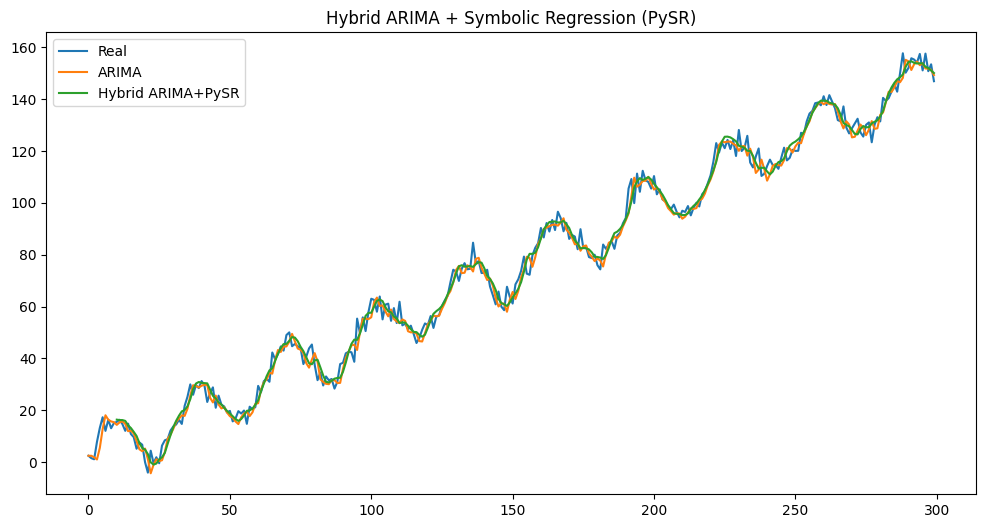

In [42]:
plt.figure(figsize=(12, 6))
plt.plot(y.values, label="Real")
plt.plot(arima_pred, label="ARIMA")
plt.plot(range(len(y)-len(hybrid_pred), len(y)), hybrid_pred, label="Hybrid ARIMA+PySR")
plt.legend()
plt.title("Hybrid ARIMA + Symbolic Regression (PySR)")
plt.show()


In [45]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

y_true = y.values[-len(hybrid_pred):]
y_arima = arima_pred[-len(hybrid_pred):]

mae_arima = mean_absolute_error(y_true, y_arima)
mse_arima = mean_squared_error(y_true, y_arima)
rmse_arima = np.sqrt(mse_arima)
r2_score_arima = r2_score(y_true, y_arima)

mae_hybrid = mean_absolute_error(y_true, hybrid_pred)
mse_hybrid = mean_squared_error(y_true, hybrid_pred)
rmse_hybrid = np.sqrt(mse_hybrid)
r2_score_hybrid = r2_score(y_true, hybrid_pred)

print(f"R^2: ARIMA={r2_score_arima:.4f} Hybrid={r2_score_hybrid:.4f}")
print(f"MAE: ARIMA={mae_arima:.4f} Hybrid={mae_hybrid:.4f}")
print(f"MSE: ARIMA={mse_arima:.4f} Hybrid={mse_hybrid:.4f}")
print(f"RMSE: ARIMA={rmse_arima:.4f} Hybrid={rmse_hybrid:.4f}")

R^2: ARIMA=0.9923 Hybrid=0.9936
MAE: ARIMA=2.9504 Hybrid=2.6815
MSE: ARIMA=14.1387 Hybrid=11.6729
RMSE: ARIMA=3.7601 Hybrid=3.4166


# Данные

In [48]:
import requests
import pandas as pd
import time
import pandas as pd
import matplotlib.pyplot as plt

In [49]:
BASE_URL = "https://api.bybit.com/v5/market/kline"
SYMBOLS = ["BTCUSDT", "ETHUSDT", "XRPUSDT"]
CATEGORY = "spot"
INTERVAL = "M"
START_DATE = "2018-01-01"


def get_monthly_data(symbol):
    start_ts = int(pd.Timestamp(START_DATE).timestamp() * 1000)
    all_rows = []
    cursor = start_ts

    while True:
        params = {"category": CATEGORY,
                  "symbol": symbol,
                  "interval": INTERVAL,
                  "start": cursor,
                  "limit": 200}
        resp = requests.get(BASE_URL, params=params).json()
        if resp["retCode"] != 0:
            raise Exception(f"Ошибка API: {resp}")
        rows = resp["result"]["list"]
        if not rows:
            break
        rows = [r for r in rows if len(str(r[0])) <= 13]
        if not rows:
            break
        all_rows.extend(rows)
        if len(rows) < 200:
            break
        cursor = int(rows[-1][0]) + 1
        time.sleep(0.2)
    if not all_rows:
        print(f"Нет данных для {symbol}")
        return None
    df = pd.DataFrame(all_rows, columns=["timestamp", "open", "high", "low", "close", "volume", "turnover"])
    df["timestamp"] = pd.to_datetime(df["timestamp"].astype("int64"), unit="ms")
    df = df.astype({"open": float, "high": float, "low": float, "close": float, "volume": float, "turnover": float})
    return df.sort_values("timestamp").drop_duplicates()


for symbol in SYMBOLS:
    df = get_monthly_data(symbol)
    if df is not None:
        filename = f"{symbol}_monthly_from_2018.csv"
        df.to_csv(filename, index=False)
    time.sleep(1)


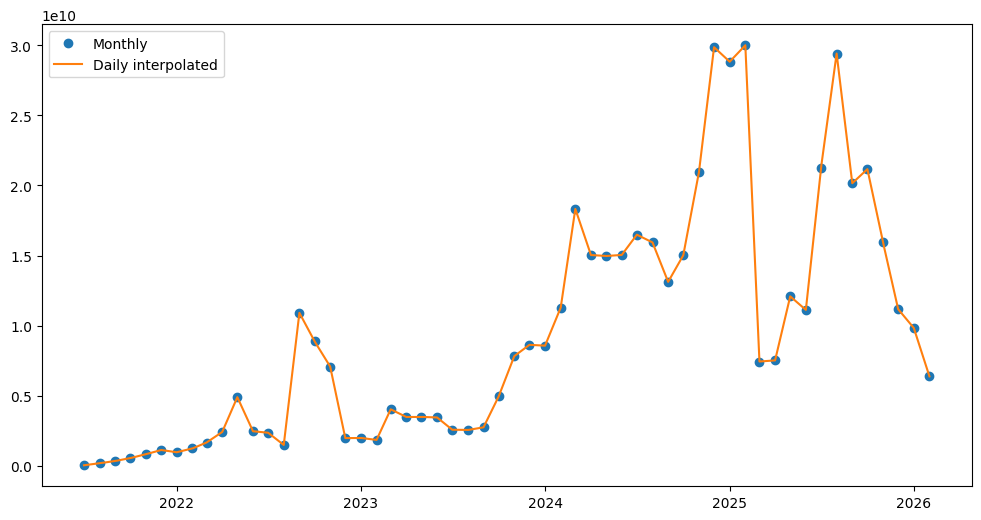

In [21]:
df_raw = pd.read_csv('ETHUSDT_monthly_from_2018.csv')
df_raw['timestamp'] = pd.to_datetime(df_raw['timestamp'])
df = df_raw.set_index('timestamp')
df = df[['turnover']]
df_daily = df.resample("D").asfreq()
df_daily['turnover'] = df_daily['turnover'].interpolate(method='linear')
df_daily.to_csv('ETHUSDT_linear_D_2018-01-01_to_2.csv')
plt.figure(figsize=(12,6))
plt.plot(df.index, df['turnover'], 'o', label='Monthly')
plt.plot(df_daily.index, df_daily['turnover'], '-', label='Daily interpolated')
plt.legend()
plt.show()

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.tsa.arima.model import ARIMA
from pysr import PySRRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

Detected IPython. Loading juliacall extension. See https://juliapy.github.io/PythonCall.jl/stable/compat/#IPython


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from statsmodels.tsa.arima.model import ARIMA
from pysr import PySRRegressor


def make_lags_two_sources(residuals, y_series, nlags=10):
    df = pd.DataFrame({"y_res": residuals,
                       "y": y_series})

    for i in range(1, nlags + 1):
        df[f"res_lag_{i}"] = df["y_res"].shift(i)

    for i in range(1, nlags + 1):
        df[f"y_lag_{i}"] = df["y"].shift(i)

    return df.dropna()


def analyze_symbol(symbol, test_size=0.2, nlags=10):
    print(f"Анализ {symbol}")

    df = pd.read_csv(f"{symbol}_linear_D_2018-01-01_to_2026.csv")
    df["timestamp_ms"] = pd.to_datetime(df["timestamp_ms"])
    df = df.sort_values("timestamp_ms")
    y = df["turnover"].values

    split = int(len(y) * (1 - test_size))
    y_train, y_test = y[:split], y[split:]

    model = ARIMA(y_train, order=(3, 1, 2))
    arima_fit = model.fit()
    arima_pred_train = arima_fit.predict(start=1, end=len(y_train) - 1)
    arima_pred_train = np.concatenate([[y_train[0]], arima_pred_train])
    residuals_train = y_train - arima_pred_train

    mean_res = residuals_train.mean()
    std_res = residuals_train.std() if residuals_train.std() != 0 else 1.0
    residuals_train_norm = (residuals_train - mean_res) / std_res

    lagged = make_lags_two_sources(residuals_train_norm, y_train, nlags=nlags)
    X_train = lagged.drop(columns=["y_res", "y"]).values
    y_res_train = lagged["y_res"].values
    sr = PySRRegressor(niterations=40,
                       unary_operators=["sin", "cos", "exp"],
                       binary_operators=["+", "-", "*", "/"],
                       model_selection="best")
    sr.fit(X_train, y_res_train)

    residuals = list(residuals_train_norm)
    y_full = list(y_train) 

    arima_preds = []
    hybrid_preds = []

    for i in range(len(y_test)):
        model = ARIMA(y_full, order=(3, 1, 2))
        arima_fit = model.fit()

        ar_pred = arima_fit.predict(start=len(y_full), end=len(y_full))[0]
        arima_preds.append(ar_pred)

        last_res = residuals[-nlags:]
        if len(last_res) < nlags:
            last_res = [0.0] * (nlags - len(last_res)) + list(last_res)

        last_y = y_full[-nlags:]
        if len(last_y) < nlags:
            last_y = [0.0] * (nlags - len(last_y)) + list(last_y)

        lag_vector = np.array(list(last_res[::-1]) + list(last_y[::-1])).reshape(1, -1)
        res_pred_norm = sr.predict(lag_vector)[0]

        res_pred = res_pred_norm * std_res + mean_res
        hybrid = ar_pred + res_pred
        hybrid_preds.append(hybrid)

        real_residual = y_test[i] - hybrid
        real_residual_norm = (real_residual - mean_res) / std_res
        residuals.append(real_residual_norm)
        y_full.append(y_test[i])
    arima_preds = np.array(arima_preds)
    hybrid_preds = np.array(hybrid_preds)

    metrics = {"MAE": (mean_absolute_error(y_test, arima_preds),
                       mean_absolute_error(y_test, hybrid_preds)),
                "MSE": (mean_squared_error(y_test, arima_preds),
                        mean_squared_error(y_test, hybrid_preds)),
                "RMSE": (np.sqrt(mean_squared_error(y_test, arima_preds)),
                         np.sqrt(mean_squared_error(y_test, hybrid_preds))),
                "R^2": (r2_score(y_test, arima_preds),
                        r2_score(y_test, hybrid_preds))}

    print("Метрики (test):")
    for m, (ar, hy) in metrics.items():
        print(f"{m}: ARIMA={ar:.4f}   Hybrid={hy:.4f}")

    plt.figure(figsize=(12, 6))
    plt.plot(y, label="Real")
    plt.plot(range(split, len(y)), arima_preds, label="ARIMA (test)")
    plt.plot(range(split, len(y)), hybrid_preds, label="Hybrid (test)")
    plt.title(f"{symbol}: ARIMA vs Hybrid (rolling refit + normalized residuals + lagged y)")
    plt.legend()
    plt.show()

    return metrics


Анализ BTCUSDT


c:\Users\User\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\statsmodels\tsa\statespace\sarimax.py:978: UserWarning: Non-invertible starting MA parameters found. Using zeros as starting parameters.
  warn('Non-invertible starting MA parameters found.'
c:\Users\User\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\pysr\sr.py:2811: UserWarning: Note: it looks like you are running in Jupyter. The progress bar will be turned off.
  warnings.warn(
[ Info: Started!



Expressions evaluated per second: 1.240e+05
Progress: 660 / 1240 total iterations (53.226%)
════════════════════════════════════════════════════════════════════════════════════════════════════
───────────────────────────────────────────────────────────────────────────────────────────────────
Complexity  Loss       Score      Equation
1           1.006e+00  0.000e+00  y = 0.00020805
3           9.153e-01  4.717e-02  y = x₆ * 0.30186
4           9.095e-01  6.321e-03  y = sin(x₆ * 0.35548)
6           9.069e-01  1.427e-03  y = sin(x₆ * 0.28292) / 0.7515
7           8.963e-01  1.183e-02  y = cos(exp(x₆ * -0.23542) * -1.515)
9           8.907e-01  3.079e-03  y = (x₆ * 0.39312) * cos(exp(-0.78792 - x₄))
10          8.754e-01  1.744e-02  y = (-0.19519 - (exp(x₆ * -0.22178) * x₆)) * -0.34574
14          8.695e-01  1.670e-03  y = (sin(1.2039 - cos(exp(x₄ - (x₆ + 1.1576)))) * x₆) * 0....
                                      89143
16          8.621e-01  4.268e-03  y = (sin(1.2039 - cos(exp(x₄ -

[ Info: Final population:
[ Info: Results saved to:
c:\Users\User\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\statsmodels\tsa\statespace\sarimax.py:978: UserWarning: Non-invertible starting MA parameters found. Using zeros as starting parameters.
  warn('Non-invertible starting MA parameters found.'
c:\Users\User\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\statsmodels\tsa\statespace\sarimax.py:978: UserWarning: Non-invertible starting MA parameters found. Using zeros as starting parameters.
  warn('Non-invertible starting MA parameters found.'
c:\Users\User\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\statsmodels\tsa\statespace\sarimax.py:978: UserWarning: Non-invertible starting MA parameters found. Using zeros as starting parameters.
  warn('Non-invertible starting MA parameters found.'
c:\Users\User\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\statsmodels\tsa\statespace\sarimax.py:978: UserWarning: Non-invertible starting MA para


Метрики (test):
MAE: ARIMA=3128695158.2312   Hybrid=2952190303.4492
MSE: ARIMA=17462041475075264512.0000   Hybrid=15408779301611372544.0000
RMSE: ARIMA=4178760758.2961   Hybrid=3925401801.2952
R^2: ARIMA=0.1449   Hybrid=0.2454


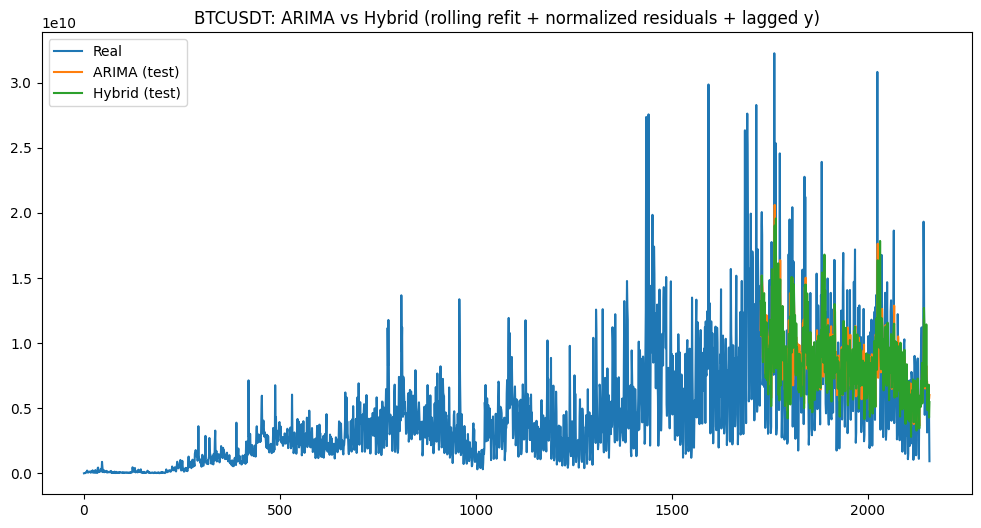

Итоговое сравнение
                                              MAE  \
BTCUSDT  (3128695158.2311807, 2952190303.4491634)   

                                                      MSE  \
BTCUSDT  (1.7462041475075265e+19, 1.5408779301611373e+19)   

                                            RMSE  \
BTCUSDT  (4178760758.2960844, 3925401801.295171)   

                                              R^2  
BTCUSDT  (0.1448530947181329, 0.2454049572180701)  
  - outputs\20260224_125215_Eb8oUp\hall_of_fame.csv


In [27]:
symbols = ["BTCUSDT"]
results = {}

for s in symbols:
    results[s] = analyze_symbol(s)

print("Итоговое сравнение")
df_results = pd.DataFrame(results).T
print(df_results)

# Пробы

In [3]:
from sklearn.model_selection import TimeSeriesSplit
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from pmdarima import auto_arima
from pysr import PySRRegressor
import sympy as sp

def make_stationary(series):
    log_series = np.log1p(series)
    diff_series = np.diff(log_series)
    return diff_series, log_series[0]


def make_lags(series, nlags=10):
    df = pd.DataFrame({"y": series})
    for i in range(1, nlags + 1):
        df[f"lag_{i}"] = df["y"].shift(i)
    return df.dropna()

def mape(y_true, y_pred): 
    y_true = np.array(y_true) 
    y_pred = np.array(y_pred) 
    mask = y_true != 0 
    if mask.sum() == 0: 
        return np.nan
    return np.mean(np.abs((y_true[mask] - y_pred[mask]) / y_true[mask])) * 100


def analyze_symbol(symbol, test_size=0.2, nlags=10, window=500, n_splits=5):
    df = pd.read_csv(f"{symbol}_linear_D_2018-01-01_to_2026.csv")
    df["timestamp_ms"] = pd.to_datetime(df["timestamp_ms"])
    df = df.sort_values("timestamp_ms")
    y_raw = df["turnover"].values

    y_stationary, log_start = make_stationary(y_raw)
    split = int(len(y_stationary) * (1 - test_size))
    y_train, y_test = y_stationary[:split], y_stationary[split:]

    arima_model = auto_arima(y_train, seasonal=False, stepwise=True, suppress_warnings=True, error_action="ignore",
                             max_p=5, max_q=5, max_d=2)
    arima_pred_train = arima_model.predict(n_periods=len(y_train))
    arima_pred_train[0] = y_train[0]
    residuals_train = y_train - arima_pred_train

    tscv = TimeSeriesSplit(n_splits=n_splits)
    cv_metrics = []

    for fold, (train_idx, val_idx) in enumerate(tscv.split(y_train)):
        y_tr = y_train[train_idx]
        y_val = y_train[val_idx]

        arima_fold = auto_arima(y_tr, seasonal=False, stepwise=True,
                                suppress_warnings=True, error_action="ignore", max_p=5, max_q=5, max_d=2)

        ar_pred_tr = arima_fold.predict(n_periods=len(y_tr))
        ar_pred_tr[0] = y_tr[0]
        res_tr = y_tr - ar_pred_tr

        lagged_tr = make_lags(res_tr, nlags=nlags)
        X_tr = lagged_tr.drop(columns=["y"]).values
        y_res_tr = lagged_tr["y"].values

        sr_cv = PySRRegressor(niterations=100,
                              unary_operators=[
                                "sin", "cos", "exp", "neg", "square", "cube",
                                "cbrt", "sqrt", "log", "asin", "acos", "sinh", "cosh",
                                "sigmoid(x) = 1 / (1 + exp(-x))",
                                "pow2(x) = x^2"],
                                binary_operators=["+", "-", "*", "/"],
                                extra_sympy_mappings={"sigmoid": lambda x: 1 / (1 + sp.exp(-x)), "pow2": lambda x: x**2},
                                model_selection="best")
        sr_cv.fit(X_tr, y_res_tr)

        ar_pred_val = arima_fold.predict(n_periods=len(y_val))
        full_res = np.concatenate([res_tr, np.zeros(len(y_val))])
        lagged_full = make_lags(full_res, nlags=nlags)

        X_val = lagged_full.drop(columns=["y"]).values[-len(y_val):]
        res_pred_val = sr_cv.predict(X_val)

        hybrid_val = ar_pred_val + res_pred_val

        fold_metrics = {"MAE": mean_absolute_error(y_val, hybrid_val), 
                        "MSE": mean_squared_error(y_val, hybrid_val), 
                        "RMSE": np.sqrt(mean_squared_error(y_val, hybrid_val)), 
                        "R2": r2_score(y_val, hybrid_val), 
                        "MAPE": mape(y_val, hybrid_val), }

        cv_metrics.append(fold_metrics)

    lagged = make_lags(residuals_train, nlags=nlags)
    X_train = lagged.drop(columns=["y"]).values
    y_res_train = lagged["y"].values

    sr = PySRRegressor(niterations=200, 
                       unary_operators=[
                        "sin", "cos", "exp", "neg", "square", "cube",
                        "cbrt", "sqrt", "log", "asin", "acos", "sinh", "cosh",
                        "sigmoid(x) = 1 / (1 + exp(-x))",
                        "pow2(x) = x^2"],
                        binary_operators=["+", "-", "*", "/"],
                        extra_sympy_mappings={"sigmoid": lambda x: 1 / (1 + sp.exp(-x)),
                                              "pow2": lambda x: x**2},
                        model_selection="best")
    sr.fit(X_train, y_res_train)

    residuals = list(residuals_train)
    arima_preds = []
    hybrid_preds = []
    for i in range(len(y_test)):
        y_available = np.concatenate([y_train, y_test[:i]])

        if len(y_available) > window:
            y_window = y_available[-window:]
        else:
            y_window = y_available

        model_refit = auto_arima(y_window, seasonal=False, stepwise=True,
                                 suppress_warnings=True, error_action="ignore", max_p=5, max_q=5, max_d=2)

        ar_pred = model_refit.predict(n_periods=1)[0]
        arima_preds.append(ar_pred)
        last_res = residuals[-nlags:]
        lag_vector = np.array(last_res[::-1]).reshape(1, -1)

        res_pred = sr.predict(lag_vector)[0]
        hybrid = ar_pred + res_pred
        hybrid_preds.append(hybrid)

        real_residual = y_test[i] - hybrid
        residuals.append(real_residual)
    arima_preds = np.array(arima_preds)
    hybrid_preds = np.array(hybrid_preds)

    metrics = {"MAE": (mean_absolute_error(y_test, arima_preds),
                       mean_absolute_error(y_test, hybrid_preds)),
            "MSE": (mean_squared_error(y_test, arima_preds),
                    mean_squared_error(y_test, hybrid_preds)),
            "RMSE": (np.sqrt(mean_squared_error(y_test, arima_preds)),
                     np.sqrt(mean_squared_error(y_test, hybrid_preds))),
            "R^2": (r2_score(y_test, arima_preds),
                    r2_score(y_test, hybrid_preds)),
            "MAPE": (mape(y_test, arima_preds),
                     mape(y_test, hybrid_preds))}

    for m, (ar, hy) in metrics.items():
        print(f"{m}: ARIMA={ar:.4f}   Hybrid={hy:.4f}")
    print("Средние метрики CV гибридной модели:")
    df_cv = pd.DataFrame(cv_metrics)
    print(df_cv.mean())

    plt.figure(figsize=(12, 6))
    plt.plot(y_stationary, label="Real (stationary)")
    plt.plot(range(split, len(y_stationary)), arima_preds, label="ARIMA (test)")
    plt.plot(range(split, len(y_stationary)), hybrid_preds, label="Hybrid (test)")
    plt.title(f"{symbol}: ARIMA vs Hybrid (stationary + rolling refit)")
    plt.legend()
    plt.show()

    return metrics, cv_metrics

c:\Users\User\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\pysr\sr.py:2811: UserWarning: Note: it looks like you are running in Jupyter. The progress bar will be turned off.
  warnings.warn(
Compiling Julia backend...
Compiling Julia backend...
[ Info: Started!



Expressions evaluated per second: 4.820e+05
Progress: 2758 / 3100 total iterations (88.968%)
════════════════════════════════════════════════════════════════════════════════════════════════════
───────────────────────────────────────────────────────────────────────────────────────────────────
Complexity  Loss       Score      Equation
1           3.068e-01  0.000e+00  y = 0.011068
3           2.864e-01  3.440e-02  y = x₀ * -0.25883
4           2.829e-01  1.240e-02  y = cbrt(x₀) * -0.2113
5           2.710e-01  4.312e-02  y = (x₁ + x₀) * -0.27956
6           2.653e-01  2.113e-02  y = (x₁ + cbrt(x₀)) * -0.25495
7           2.484e-01  6.589e-02  y = ((x₁ + x₂) + x₀) * -0.33856
8           2.454e-01  1.196e-02  y = (cbrt(x₀) + (x₂ + x₁)) * -0.29632
10          2.430e-01  5.028e-03  y = ((cbrt(0.075001 - x₀) - x₂) - x₁) * 0.30092
11          2.407e-01  9.481e-03  y = ((0.071162 - (x₂ + (x₄ + x₀))) - x₁) * 0.30125
12          2.378e-01  1.187e-02  y = (((0.080986 - (x₂ + x₀)) - x₄) - sinh(x

[ Info: Final population:
[ Info: Results saved to:
c:\Users\User\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\pysr\sr.py:2811: UserWarning: Note: it looks like you are running in Jupyter. The progress bar will be turned off.
  warnings.warn(


  - outputs\20260312_181520_pmhiG1\hall_of_fame.csv

Expressions evaluated per second: 2.760e+05
Progress: 1721 / 3100 total iterations (55.516%)
════════════════════════════════════════════════════════════════════════════════════════════════════
───────────────────────────────────────────────────────────────────────────────────────────────────
Complexity  Loss       Score      Equation
1           2.227e-01  0.000e+00  y = 0.005795
3           2.030e-01  4.640e-02  y = x₀ * -0.29806
4           2.028e-01  8.718e-04  y = cbrt(x₀) * -0.20706
5           1.967e-01  3.092e-02  y = (x₀ + x₁) * -0.28846
6           1.939e-01  1.390e-02  y = (x₁ + cbrt(x₀)) * -0.23922
7           1.935e-01  2.050e-03  y = (x₀ - (x₁ / -1.6812)) * -0.362
8           1.927e-01  4.501e-03  y = sin(x₀ - (x₁ * -0.58821)) * -0.42398
9           1.809e-01  6.315e-02  y = ((x₀ + x₁) * -0.37091) - (x₂ * 0.28285)
10          1.806e-01  1.496e-03  y = (sin(x₁ + x₀) * -0.44782) - (x₂ * 0.2836)
11          1.793e-01  7.47

[ Info: Started!
[ Info: Final population:
[ Info: Results saved to:
c:\Users\User\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\pysr\sr.py:2811: UserWarning: Note: it looks like you are running in Jupyter. The progress bar will be turned off.
  warnings.warn(


...


Expressions evaluated per second: 2.530e+05
Progress: 1490 / 3100 total iterations (48.065%)
════════════════════════════════════════════════════════════════════════════════════════════════════
───────────────────────────────────────────────────────────────────────────────────────────────────
Complexity  Loss       Score      Equation
1           2.068e-01  0.000e+00  y = 0.003576
3           1.898e-01  4.290e-02  y = x₀ / -3.4855
4           1.898e-01  1.552e-04  y = sin(x₀ / -3.4366)
5           1.831e-01  3.586e-02  y = (x₀ + x₁) / -3.9192
7           1.720e-01  3.139e-02  y = (x₀ + (x₂ + x₁)) / -3.0903
9           1.709e-01  3.256e-03  y = (x₀ - (x₆ - (x₁ + x₂))) / -3.9003
10          1.696e-01  7.266e-03  y = ((x₀ - (sin(x₆) - x₁)) + x₂) / -3.981
11          1.661e-01  2.093e-02  y = ((x₀ / 0.6157) - (x₆ - (x₂ + x₁))) / -4.4008
12          1.653e-01  5.186e-03  y = ((x₀ / 0.61669) - (sin(x₆) - (x₂ + x₁))) / -3.981
13          1.625e-01  1.698e-02  y = (x₀ - (((x₆ - x₄) * 0.42768)

[ Info: Final population:
[ Info: Results saved to:
c:\Users\User\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\pysr\sr.py:2811: UserWarning: Note: it looks like you are running in Jupyter. The progress bar will be turned off.
  warnings.warn(
[ Info: Started!



Expressions evaluated per second: 2.290e+05
Progress: 1388 / 3100 total iterations (44.774%)


[ Info: Final population:
[ Info: Results saved to:
c:\Users\User\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\pysr\sr.py:2811: UserWarning: Note: it looks like you are running in Jupyter. The progress bar will be turned off.
  warnings.warn(
[ Info: Started!
[ Info: Final population:
[ Info: Results saved to:
c:\Users\User\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\pysr\sr.py:2811: UserWarning: Note: it looks like you are running in Jupyter. The progress bar will be turned off.
  warnings.warn(
[ Info: Started!
[ Info: Final population:
[ Info: Results saved to:


MAE: ARIMA=0.3757   Hybrid=0.3713
MSE: ARIMA=0.2388   Hybrid=0.2287
RMSE: ARIMA=0.4886   Hybrid=0.4782
R^2: ARIMA=0.3972   Hybrid=0.4226
MAPE: ARIMA=860.1374   Hybrid=870.5239
Средние метрики CV гибридной модели:
MAE       0.397113
MSE       0.259213
RMSE      0.502228
R2        0.126296
MAPE    163.276751
dtype: float64


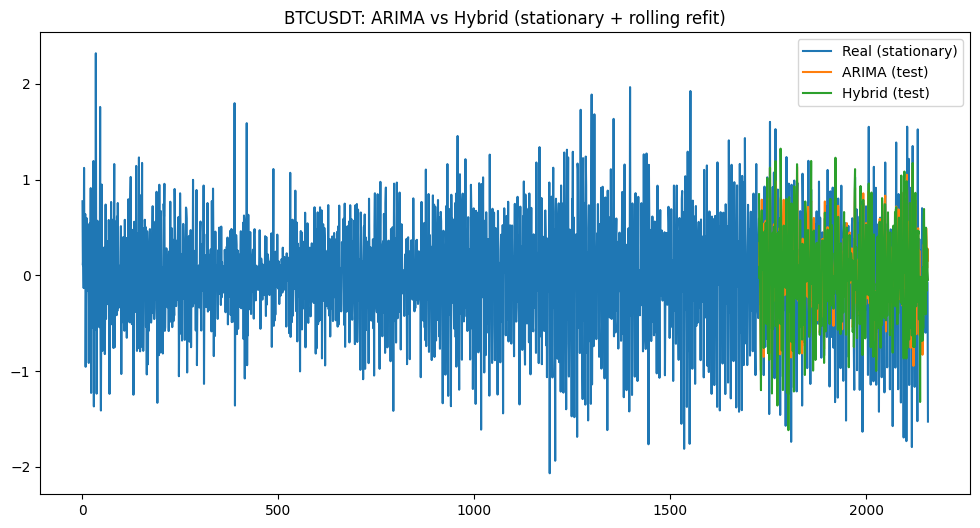

Итоговое сравнение
                                               MAE  \
BTCUSDT  (0.3756728272264305, 0.37132630351373724)   

                                               MSE  \
BTCUSDT  (0.2387567691035121, 0.22869526083735867)   

                                            RMSE  \
BTCUSDT  (0.4886274338425055, 0.478220933081519)   

                                               R^2  \
BTCUSDT  (0.39719133644033244, 0.4225944459483396)   

                                           MAPE  
BTCUSDT  (860.1373646139962, 870.5238560565508)  
Error in callback _flush_stdio (for post_execute), with arguments args (),kwargs {}:


UnicodeDecodeError: 'utf-8' codec can't decode bytes in position 4094-4095: unexpected end of data

In [4]:
symbols = ["BTCUSDT"]
results = {}

for s in symbols:
    results[s], _ = analyze_symbol(s)

print("Итоговое сравнение")
df_results = pd.DataFrame(results).T
print(df_results)

Удаляем object-колонки: ['datetime']
Training until validation scores don't improve for 500 rounds
[100]	training's rmse: 1120.47	valid_1's rmse: 9351.79
[200]	training's rmse: 228.524	valid_1's rmse: 7784.15
[300]	training's rmse: 187.372	valid_1's rmse: 7642.84
[400]	training's rmse: 166.732	valid_1's rmse: 7616.65
[500]	training's rmse: 149.509	valid_1's rmse: 7636.75
[600]	training's rmse: 136.541	valid_1's rmse: 7656.23
[700]	training's rmse: 125.315	valid_1's rmse: 7636.18
[800]	training's rmse: 116.324	valid_1's rmse: 7631.82
[900]	training's rmse: 105.947	valid_1's rmse: 7644.59
Early stopping, best iteration is:
[435]	training's rmse: 161.347	valid_1's rmse: 7614.12


c:\Users\User\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\pysr\sr.py:2811: UserWarning: Note: it looks like you are running in Jupyter. The progress bar will be turned off.
  warnings.warn(
[ Info: Started!



Expressions evaluated per second: 1.620e+05
Progress: 917 / 6200 total iterations (14.790%)
════════════════════════════════════════════════════════════════════════════════════════════════════
───────────────────────────────────────────────────────────────────────────────────────────────────
Complexity  Loss       Score      Equation
1           2.603e+04  0.000e+00  y = 0.61128
2           2.602e+04  -0.000e+00  y = sin(x₁₂)
3           2.599e+04  -0.000e+00  y = x₁₇ * x₂₇
4           2.598e+04  -0.000e+00  y = sin(x₄) * -10.511
5           2.580e+04  4.771e-03  y = (x₁₈ * x₅) * 7.3903e-08
6           2.564e+04  4.395e-03  y = (x₅ * 4.8558e-09) * sin(x₁₂)
7           2.561e+04  -0.000e+00  y = sin(sin(x₁₂)) * (x₅ * 5.7383e-09)
8           2.529e+04  1.070e-02  y = x₅ * (cos(x₅ * -0.0084846) * 6.5616e-09)
10          2.523e+04  2.497e-04  y = ((-1.2786e-08 * x₂) * x₂) * sin(x₂₈ + x₁₃)
12          2.516e+04  3.191e-04  y = sin((x₂₈ + x₁₃) + x₂₂) * (x₂ * (-1.2795e-08 * x₂))
14          

[ Info: Final population:
[ Info: Results saved to:


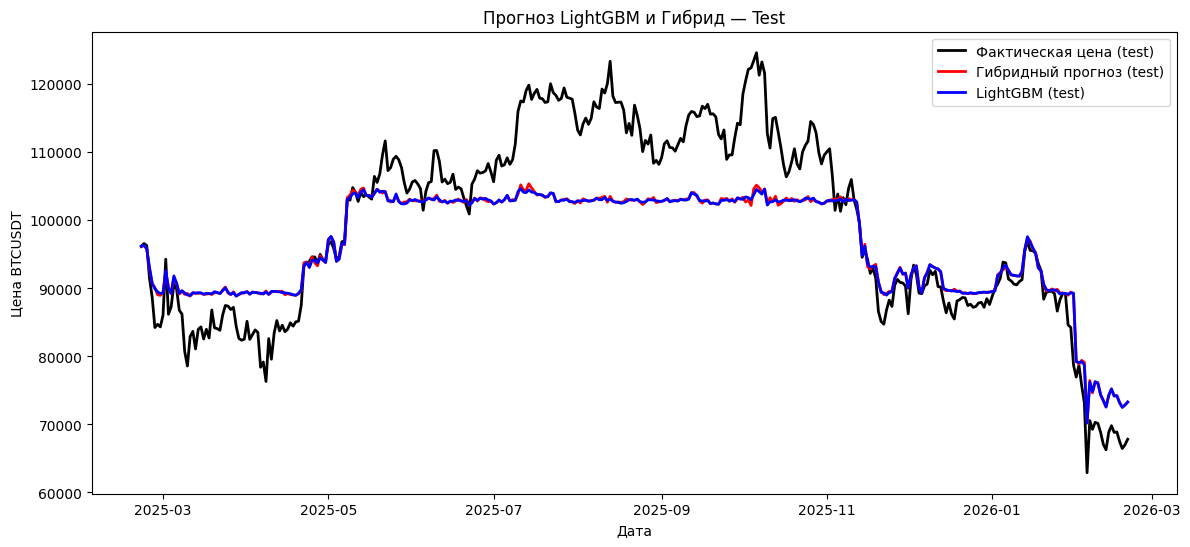

In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import lightgbm as lgb
from pysr import PySRRegressor

df = pd.read_csv("BTCUSDT_linear_D_2018-01-01_to_2026.csv")
df["date"] = pd.to_datetime(df["date"])
df = df.sort_values("date").reset_index(drop=True)

date_col = df["date"]
for lag in [1, 2, 3, 7, 14, 30]:
    df[f"lag_{lag}"] = df["close"].shift(lag)

df["ma_7"] = df["close"].rolling(7).mean().shift(1)
df["ma_14"] = df["close"].rolling(14).mean().shift(1)
df["ma_30"] = df["close"].rolling(30).mean().shift(1)
df["vol_7"] = df["close"].rolling(7).std().shift(1)
df["vol_14"] = df["close"].rolling(14).std().shift(1)
df["log_close"] = np.log(df["close"])
df["log_return_1"] = df["log_close"].diff().shift(1)
df["log_return_7"] = df["log_close"].diff(7).shift(1)
df["log_return_14"] = df["log_close"].diff(14).shift(1)

df["momentum_7"] = df["close"] / df["close"].shift(7) - 1
df["momentum_14"] = df["close"] / df["close"].shift(14) - 1

def trend_slope(x):
    y = np.array(x)
    x_idx = np.arange(len(x))
    return np.polyfit(x_idx, y, 1)[0]

df["trend_7"] = df["close"].rolling(7).apply(trend_slope).shift(1)
df["trend_14"] = df["close"].rolling(14).apply(trend_slope).shift(1)
df["trend_30"] = df["close"].rolling(30).apply(trend_slope).shift(1)
df["t"] = np.arange(len(df))
df["dow_sin"] = np.sin(2 * np.pi * df["date"].dt.dayofweek / 7)
df["dow_cos"] = np.cos(2 * np.pi * df["date"].dt.dayofweek / 7)

df = df.drop(columns=["date"])
object_cols = df.select_dtypes(include=["object"]).columns
if len(object_cols) > 0:
    print("Удаляем object-колонки:", object_cols.tolist())
    df = df.drop(columns=object_cols)

df = df.dropna().reset_index(drop=True)
target = "close"
features = [c for c in df.columns if c != target]

X = df[features]
y = df[target]
test_size = 365
X_train, X_test = X.iloc[:-test_size], X.iloc[-test_size:]
y_train, y_test = y.iloc[:-test_size], y.iloc[-test_size:]
test_dates = date_col.iloc[-test_size:]
params = {"objective": "regression",
          "metric": "rmse",
          "learning_rate": 0.03,
          "num_leaves": 64,
          "feature_fraction": 0.9,
          "bagging_fraction": 0.8,
          "bagging_freq": 5,
          "verbose": -1}

train_data = lgb.Dataset(X_train, label=y_train)
valid_data = lgb.Dataset(X_test, label=y_test)
callbacks = [lgb.early_stopping(stopping_rounds=500),
             lgb.log_evaluation(period=100)]

model_lgbm = lgb.train(params, train_data, valid_sets=[train_data, valid_data],
                       num_boost_round=5000, callbacks=callbacks)

y_pred_train = model_lgbm.predict(X_train)
y_pred_test_lgbm = model_lgbm.predict(X_test)
residuals_train = y_train - y_pred_train

model_pysr = PySRRegressor(niterations=200, maxsize=14, maxdepth=5, model_selection="best",
                           unary_operators=["sin", "cos"], binary_operators=["+", "-", "*"])
model_pysr.fit(X_train.values, residuals_train.values)

residuals_pred_test = model_pysr.predict(X_test.values)
y_pred_test_hybrid = y_pred_test_lgbm + residuals_pred_test
mae = mean_absolute_error(y_test, y_pred_test_hybrid)
rmse = np.sqrt(mean_squared_error(y_test, y_pred_test_hybrid))
r2 = r2_score(y_test, y_pred_test_hybrid)
mape = np.mean(np.abs((y_test - y_pred_test_hybrid) / y_test)) * 100

print("Hybrid MAE:", mae)
print("Hybrid RMSE:", rmse)
print("Hybrid R2:", r2)
print("Hybrid MAPE:", mape)

plt.figure(figsize=(14, 6))
plt.plot(test_dates, y_test.values, label="Фактическая цена (test)", linewidth=2, color="black")
plt.plot(test_dates, y_pred_test_hybrid, label="Гибридный прогноз (test)", linewidth=2, color="red")
plt.plot(test_dates, y_pred_test_lgbm, label="LightGBM (test)", linewidth=2, color="blue")
plt.title("Прогноз LightGBM и Гибрид — Test")
plt.xlabel("Дата")
plt.ylabel("Цена BTCUSDT")
plt.legend()
plt.show()

c:\Users\User\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\pysr\sr.py:2811: UserWarning: Note: it looks like you are running in Jupyter. The progress bar will be turned off.
  warnings.warn(
[ Info: Started!



Expressions evaluated per second: 2.380e+05
Progress: 1165 / 9300 total iterations (12.527%)
════════════════════════════════════════════════════════════════════════════════════════════════════
───────────────────────────────────────────────────────────────────────────────────────────────────
Complexity  Loss       Score      Equation
1           4.691e+06  0.000e+00  y = x₁₀
3           4.020e+06  -0.000e+00  y = x₁₀ + x₂₂
5           3.629e+06  -0.000e+00  y = x₁₀ + (x₂₂ / 0.39345)
7           3.010e+06  -0.000e+00  y = ((x₁₀ + x₁₂) + 771.32) * 0.492
9           2.993e+06  -0.000e+00  y = (x₁₀ * 0.54003) + ((x₁₂ / 2.2514) - -388.47)
11          2.990e+06  -0.000e+00  y = ((x₁₂ * 0.44285) + (x₁₀ / 1.852)) - (x₁₅ * -42.84)
13          2.988e+06  -0.000e+00  y = ((x₁₀ / 1.8739) + (x₁₂ * 0.45113)) - ((3.8594 - x₁₈) ...
                                       * -94.033)
14          2.980e+06  -0.000e+00  y = (x₁₂ / 2.2549) + ((x₁₀ * 0.5407) - (-387.93 + (x₁₅ / ...
                        

[ Info: Final population:
[ Info: Results saved to:


Hybrid MAE: 1084.9585018310754
Hybrid RMSE: 1541.280652347891
Hybrid R2: 0.9879511582926965
Hybrid MAPE: 1.1342438477394694


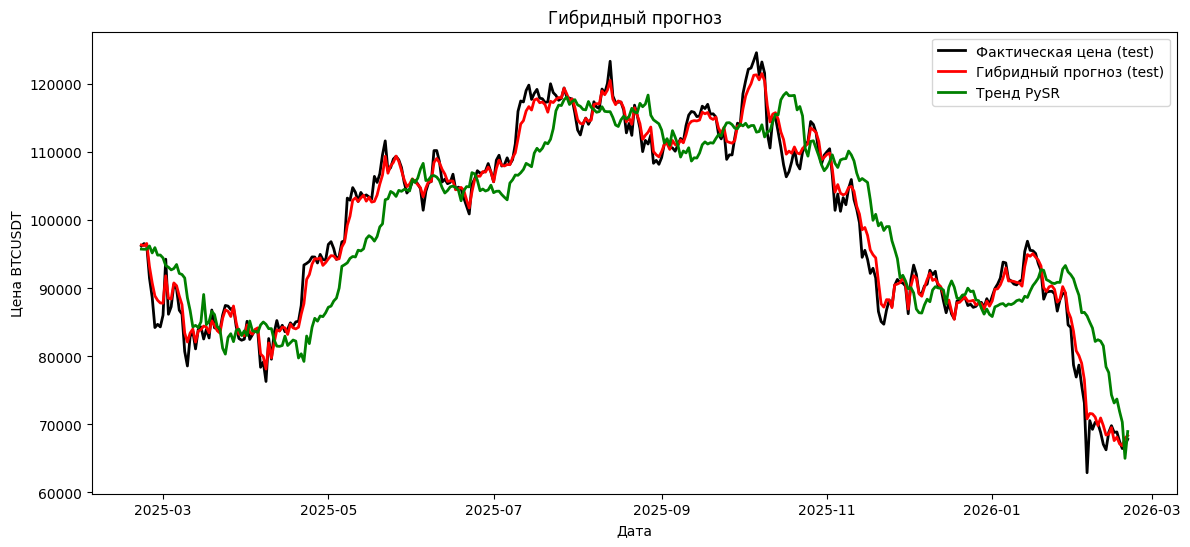

In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from xgboost import XGBRegressor
from pysr import PySRRegressor

df = pd.read_csv("BTCUSDT_linear_D_2018-01-01_to_2026.csv")
df["date"] = pd.to_datetime(df["date"])
df = df.sort_values("date").reset_index(drop=True)
date_col = df["date"]
for lag in [1, 2, 3, 7, 14]:
    df[f"lag_{lag}"] = df["close"].shift(lag)
df["ma_7"] = df["close"].rolling(7).mean().shift(1)
df["ma_14"] = df["close"].rolling(14).mean().shift(1)
df["vol_7"] = df["close"].rolling(7).std().shift(1)
df["vol_14"] = df["close"].rolling(14).std().shift(1)
df["log_close"] = np.log(df["close"])
df["log_return_1"] = df["log_close"].diff().shift(1)
df["log_return_7"] = df["log_close"].diff(7).shift(1)
df["log_return_14"] = df["log_close"].diff(14).shift(1)
df["momentum_7"] = df["close"] / df["close"].shift(7) - 1
df["momentum_14"] = df["close"] / df["close"].shift(14) - 1

def trend_slope(x):
    y = np.array(x)
    x_idx = np.arange(len(x))
    return np.polyfit(x_idx, y, 1)[0]

df["trend_7"] = df["close"].rolling(7).apply(trend_slope).shift(1)
df["trend_14"] = df["close"].rolling(14).apply(trend_slope).shift(1)
df["t"] = np.arange(len(df))
df["dow_sin"] = np.sin(2 * np.pi * df["date"].dt.dayofweek / 7)
df["dow_cos"] = np.cos(2 * np.pi * df["date"].dt.dayofweek / 7)
df["trend_target"] = df["close"].rolling(30).mean().shift(1)

df = df.drop(columns=["date"])
object_cols = df.select_dtypes(include=["object"]).columns
df = df.drop(columns=object_cols)
df = df.dropna().reset_index(drop=True)

target = "close"
trend_target = df["trend_target"]
features = [c for c in df.columns if c not in [target, "trend_target"]]

X = df[features]
y = df[target]

test_size = 365
X_train, X_test = X.iloc[:-test_size], X.iloc[-test_size:]
y_train, y_test = y.iloc[:-test_size], y.iloc[-test_size:]
trend_train, trend_test = trend_target.iloc[:-test_size], trend_target.iloc[-test_size:]
test_dates = date_col.iloc[-test_size:]
model_pysr = PySRRegressor(niterations=300, maxsize=16, maxdepth=6,
                           model_selection="best", unary_operators=["sin", "cos", "exp", "log"],
                           binary_operators=["+", "-", "*", "/"])
model_pysr.fit(X_train.values, trend_train.values)

trend_pred_train = model_pysr.predict(X_train.values)
trend_pred_test = model_pysr.predict(X_test.values)
y_train_detrended = y_train.values - trend_pred_train

model_xgb = XGBRegressor(n_estimators=1500, learning_rate=0.02, max_depth=8,
                         subsample=0.8, colsample_bytree=0.8, objective="reg:squarederror")
model_xgb.fit(X_train, y_train_detrended)

oscillation_pred_test = model_xgb.predict(X_test)
y_pred_test_hybrid = trend_pred_test + oscillation_pred_test

mae = mean_absolute_error(y_test, y_pred_test_hybrid)
rmse = np.sqrt(mean_squared_error(y_test, y_pred_test_hybrid))
r2 = r2_score(y_test, y_pred_test_hybrid)
mape = np.mean(np.abs((y_test - y_pred_test_hybrid) / y_test)) * 100

print("Hybrid MAE:", mae)
print("Hybrid RMSE:", rmse)
print("Hybrid R2:", r2)
print("Hybrid MAPE:", mape)

plt.figure(figsize=(14, 6))
plt.plot(test_dates, y_test.values, label="Фактическая цена (test)", linewidth=2, color="black")
plt.plot(test_dates, y_pred_test_hybrid, label="Гибридный прогноз (test)", linewidth=2, color="red")
plt.plot(test_dates, trend_pred_test, label="Тренд PySR", linewidth=2, color="green")
plt.title("Гибридный прогноз")
plt.xlabel("Дата")
plt.ylabel("Цена BTCUSDT")
plt.legend()
plt.show()